# 🩺 PFA — Diabète de Type 2 (Pima Indians)
### Pipeline ML complet · Version corrigée & améliorée
---

## 1 · Importations & Configuration

In [12]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
# Déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non installé — pip install xgboost")

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
print("✓ Importations OK")


✓ Importations OK


## 2 · Chargement & Exploration

Shape : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000



Valeurs manquantes : 0


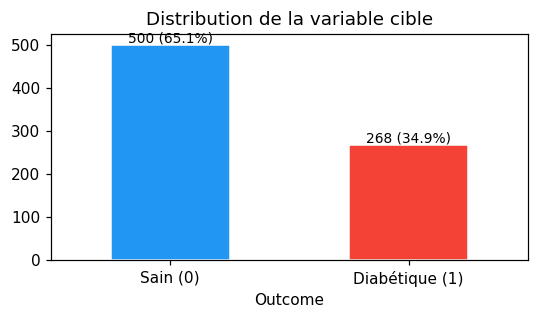

In [2]:
df = pd.read_csv('diabetes.csv')
print(f"Shape : {df.shape}")
display(df.head())
display(df.describe().T.style.background_gradient(cmap='Blues'))
print("\nValeurs manquantes :", df.isnull().sum().sum())

# Distribution cible
fig, ax = plt.subplots(figsize=(5, 3))
df['Outcome'].value_counts().plot.bar(ax=ax, color=['#2196F3','#F44336'], edgecolor='white')
ax.set_xticklabels(['Sain (0)', 'Diabétique (1)'], rotation=0)
ax.set_title('Distribution de la variable cible')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x()+p.get_width()/2, p.get_height()+5), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 3 · Prétraitement

In [3]:
# --- 3.1 Remplacement des zéros biologiquement impossibles ---
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
print("NaN après remplacement des zéros :")
print(df[zero_cols].isnull().sum())

# ---# --- 3.2 Imputation par la médiane ---
imputer = SimpleImputer(strategy='median')
X_raw = df.drop('Outcome', axis=1)
y_raw = df['Outcome']
df_imp = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
df_imp['Outcome'] = y_raw.values
print(f"\nValeurs manquantes après imputation : {df_imp.isnull().sum().sum()}")

# --- 3.3 Séparation features / cible ---
X = df_imp.drop('Outcome', axis=1)
y = df_imp['Outcome'].astype(int)
feature_names = X.columns.tolist()

# --- 3.4 Split stratifié (CORRIGÉ : stratify=y) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)  # ← stratify ajouté
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Proportion cible train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

# --- 3.5 Standardisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- 3.6 SMOTE sur le train uniquement (NOUVEAU) ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"\nAprès SMOTE → Train : {len(y_train_bal)} | Classe 0: {(y_train_bal==0).sum()} | Classe 1: {(y_train_bal==1).sum()}")

NaN après remplacement des zéros :
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Valeurs manquantes après imputation : 0
Train : 614 | Test : 154
Proportion cible train : 0.349 | test : 0.351

Après SMOTE → Train : 800 | Classe 0: 400 | Classe 1: 400


## 4 · Entraînement des Modèles

In [4]:
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décision":     DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest":         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM":                   SVC(probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(n_estimators=200, use_label_encoder=False,
                                       eval_metric='logloss', random_state=RANDOM_STATE)

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred      = model.predict(X_test_sc)
    y_proba     = model.predict_proba(X_test_sc)[:, 1]
    cv_scores   = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_proba),
        'CV-AUC (mean)': cv_scores.mean(),
        'CV-AUC (std)':  cv_scores.std(),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        '_model': model,
        '_y_proba': y_proba,
    }
    print(f"  {name:<25} Acc={results[name]['Accuracy']:.3f} | F1={results[name]['F1-score']:.3f} | AUC={results[name]['AUC-ROC']:.3f} | CV-AUC={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

  Régression Logistique     Acc=0.714 | F1=0.621 | AUC=0.811 | CV-AUC=0.842±0.017
  Arbre de Décision         Acc=0.721 | F1=0.656 | AUC=0.727 | CV-AUC=0.795±0.028
  Random Forest             Acc=0.753 | F1=0.672 | AUC=0.812 | CV-AUC=0.901±0.020
  SVM                       Acc=0.727 | F1=0.638 | AUC=0.811 | CV-AUC=0.871±0.026
  Gradient Boosting         Acc=0.753 | F1=0.672 | AUC=0.817 | CV-AUC=0.876±0.016
  XGBoost                   Acc=0.740 | F1=0.636 | AUC=0.800 | CV-AUC=0.883±0.013


## 5 · Évaluation & Visualisations

In [5]:
# --- 5.1 Tableau comparatif ---
metrics_df = pd.DataFrame({k: {m: v for m, v in vv.items()
                                if not m.startswith('_') and m != 'Confusion Matrix'}
                           for k, vv in results.items()}).T
display(metrics_df.style.highlight_max(axis=0, color='#d4f0c0').format("{:.4f}"))

best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f"\n Meilleur modèle (AUC-ROC) : {best_model_name}")

,Accuracy,Precision,Recall,F1-score,AUC-ROC,CV-AUC (mean),CV-AUC (std)
Régression Logistique,0.7143,0.5806,0.6667,0.6207,0.8115,0.8421,0.0171
Arbre de Décision,0.7208,0.5775,0.7593,0.6560,0.7272,0.7952,0.0284
Random Forest,0.7532,0.6290,0.7222,0.6724,0.8120,0.9007,0.0199
SVM,0.7273,0.5968,0.6852,0.6379,0.8114,0.8715,0.0263
Gradient Boosting,0.7532,0.6290,0.7222,0.6724,0.8172,0.8763,0.0163
XGBoost,0.7403,0.6250,0.6481,0.6364,0.8004,0.8835,0.0130



 Meilleur modèle (AUC-ROC) : Gradient Boosting


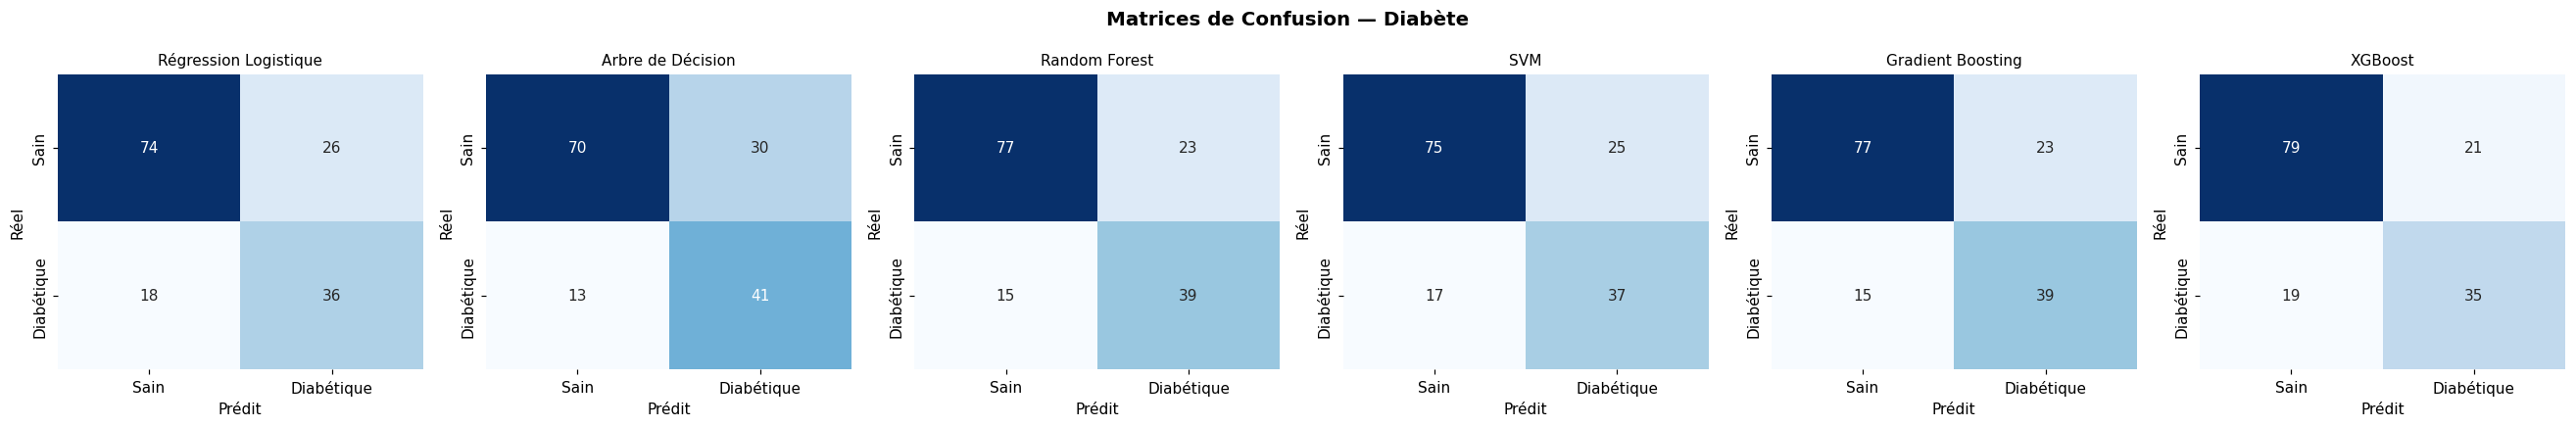

In [6]:
# --- 5.2 Matrices de confusion ---
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False, xticklabels=['Sain','Diabétique'],
                yticklabels=['Sain','Diabétique'])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Prédit'); axes[i].set_ylabel('Réel')
plt.suptitle('Matrices de Confusion — Diabète', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

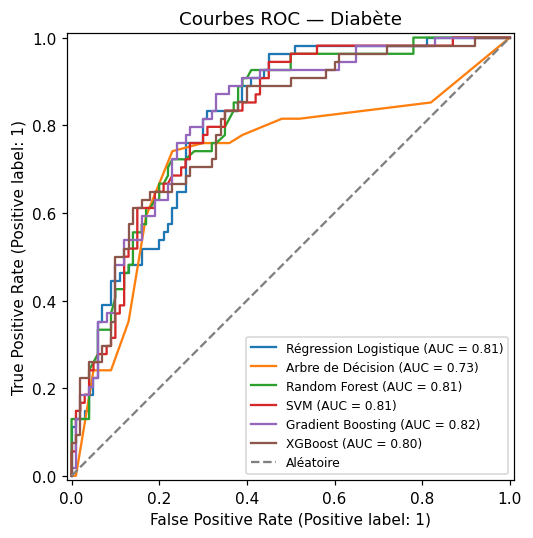

In [7]:
# --- 5.3 Courbes ROC superposées (NOUVEAU) ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['_y_proba'], name=name, ax=ax)
ax.plot([0,1],[0,1],'--', color='gray', label='Aléatoire')
ax.set_title('Courbes ROC — Diabète')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

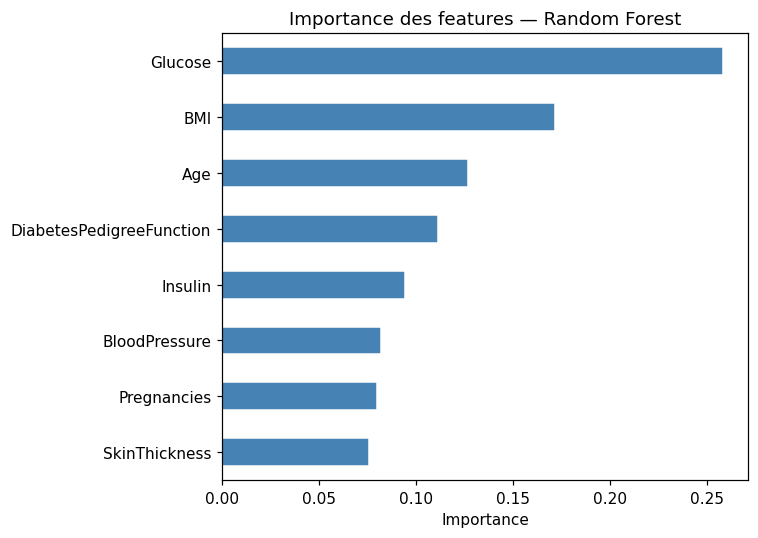

In [8]:
# --- 5.4 Feature Importance — Random Forest (NOUVEAU) ---
rf = results['Random Forest']['_model']
feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importance des features — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 6 · Sauvegarde du meilleur modèle

In [9]:
best_model = results[best_model_name]['_model']
joblib.dump(best_model, 'model_diabetes.pkl')
joblib.dump(scaler,     'scaler_diabetes.pkl')
joblib.dump(imputer,    'imputer_diabetes.pkl')
print(f"✓ Modèle '{best_model_name}' sauvegardé → model_diabetes.pkl")
print(f"✓ Scaler sauvegardé → scaler_diabetes.pkl")

# Vérification chargement
loaded = joblib.load('model_diabetes.pkl')
print(f"✓ Vérification chargement OK — type : {type(loaded).__name__}")

✓ Modèle 'Gradient Boosting' sauvegardé → model_diabetes.pkl
✓ Scaler sauvegardé → scaler_diabetes.pkl
✓ Vérification chargement OK — type : GradientBoostingClassifier


## 7 · Rapport de classification du meilleur modèle

In [10]:
y_pred_best = best_model.predict(X_test_sc)
print(f"Rapport — {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['Sain','Diabétique']))

Rapport — Gradient Boosting
              precision    recall  f1-score   support

        Sain       0.84      0.77      0.80       100
  Diabétique       0.63      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154

